<a href="https://colab.research.google.com/github/sakethnandam/exoplanet-detection/blob/sakethnandam-patch-1/1D_Autoencoder_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.8/201.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 88.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.1.0 which is incompatible.
datasets 4.0.0 re

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Using device: cpu


/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 18 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


Total flux points: 469
Windows shape: (1, 512)
Dataset size: 1
Epoch 01/30 | Loss: 0.133964
Epoch 02/30 | Loss: 0.122071
Epoch 03/30 | Loss: 0.111102
Epoch 04/30 | Loss: 0.100902
Epoch 05/30 | Loss: 0.089986
Epoch 06/30 | Loss: 0.079005
Epoch 07/30 | Loss: 0.068269
Epoch 08/30 | Loss: 0.058260
Epoch 09/30 | Loss: 0.049735
Epoch 10/30 | Loss: 0.044232
Epoch 11/30 | Loss: 0.043201
Epoch 12/30 | Loss: 0.042908
Epoch 13/30 | Loss: 0.039249
Epoch 14/30 | Loss: 0.034240
Epoch 15/30 | Loss: 0.031447
Epoch 16/30 | Loss: 0.032119
Epoch 17/30 | Loss: 0.030318
Epoch 18/30 | Loss: 0.025495
Epoch 19/30 | Loss: 0.021190
Epoch 20/30 | Loss: 0.018898
Epoch 21/30 | Loss: 0.017459
Epoch 22/30 | Loss: 0.015789
Epoch 23/30 | Loss: 0.014085
Epoch 24/30 | Loss: 0.013166
Epoch 25/30 | Loss: 0.012668
Epoch 26/30 | Loss: 0.011606
Epoch 27/30 | Loss: 0.009785
Epoch 28/30 | Loss: 0.007854
Epoch 29/30 | Loss: 0.006567
Epoch 30/30 | Loss: 0.006240


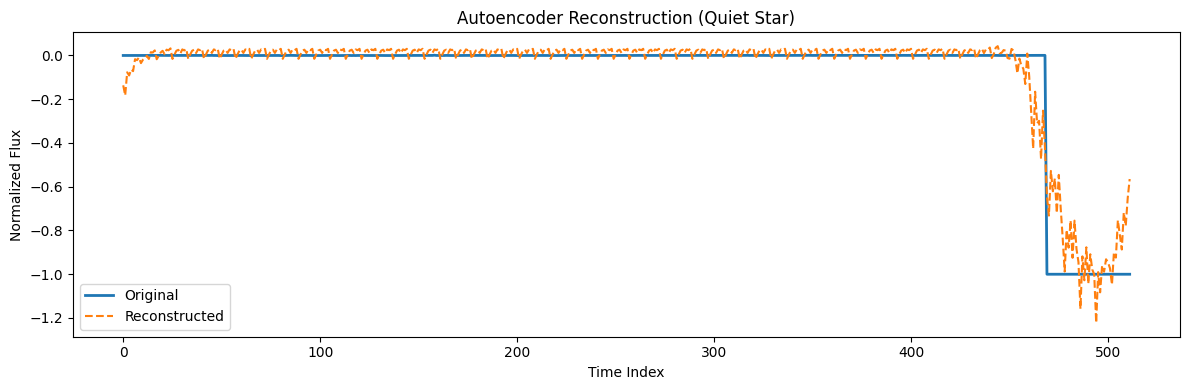

In [1]:
!pip install -q lightkurve

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightkurve as lk
import matplotlib.pyplot as plt

WINDOW_SIZE = 512
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

lc = lk.search_lightcurve("KIC 757076", mission="Kepler").download()

lc = lc.remove_nans().normalize()

flux = lc.flux.value.astype(np.float32)

print("Total flux points:", len(flux))

def make_windows(flux, window_size):
    windows = []

    if len(flux) < window_size:
        padded = np.zeros(window_size, dtype=np.float32)
        padded[:len(flux)] = flux
        median = np.median(padded[padded != 0])
        padded = padded / median - 1.0
        windows.append(padded)
    else:
        for i in range(0, len(flux) - window_size + 1, window_size):
            window = flux[i:i + window_size]
            window = window / np.median(window) - 1.0
            windows.append(window)

    return np.stack(windows)

X = make_windows(flux, WINDOW_SIZE)

print("Windows shape:", X.shape)

assert len(X) > 0, "ERROR: No windows created!"

class LightCurveDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx].unsqueeze(0)

dataset = LightCurveDataset(X)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Dataset size:", len(dataset))

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = ConvAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.6f}")

model.eval()

sample = dataset[0].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    recon = model(sample)

orig = sample[0, 0].cpu().numpy()
recon = recon[0, 0].cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(orig, label="Original", linewidth=2)
plt.plot(recon, label="Reconstructed", linestyle="--")
plt.legend()
plt.title("Autoencoder Reconstruction (Quiet Star)")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.tight_layout()
plt.show()
